In [ ]:
# ============================================================
# ARGENTINA vs FRANCE — Analyse Coupe du Monde 2022
# ============================================================
# Sections :
#   0. Setup & chargement des données
#   1. Histoire du football — palmarès & confrontations
#   2. Coupe du Monde 2022 — context & classement FIFA
#   3. Danger passes — cartes & heatmaps (côte à côte)
#   4. Dashboard synthèse

# ============================================================
# 0. SETUP & CHARGEMENT DES DONNÉES
# ============================================================


In [ ]:

from statsbombpy import sb
import pandas as pd
import os
import kagglehub
import shutil
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from mplsoccer import Pitch, Sbopen
import sys
from matplotlib.patches import FancyBboxPatch

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

os.makedirs("../reports/figures", exist_ok=True)
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

# Téléchargement et copie des datasets
path1 = kagglehub.dataset_download("anassaleh98/fifaworldcup2022")
path2 = kagglehub.dataset_download("shilongzhuang/soccer-world-cup-challenge")

for path in [path1, path2]:
    for f in os.listdir(path):
        if f.endswith(".csv"):
            shutil.copy(os.path.join(path, f), f"../data/raw/{f}")

# Chargement
matches_2022    = pd.read_csv("../data/raw/matches_2022.csv")
rank            = pd.read_csv("../data/raw/rank.csv")
results         = pd.read_csv("../data/raw/results.csv")
groups          = pd.read_csv("../data/raw/2022_world_cup_groups.csv")
wc_matches_2022 = pd.read_csv("../data/raw/2022_world_cup_matches.csv")
int_matches     = pd.read_csv("../data/raw/international_matches.csv")
world_cups      = pd.read_csv("../data/raw/world_cups.csv")
wc_matches      = pd.read_csv("../data/raw/world_cup_matches.csv")

int_matches["Year"] = pd.to_datetime(int_matches["Date"], errors="coerce").dt.year

# StatsBomb — matchs WC 2022
parser = Sbopen()
df_match = parser.match(competition_id=43, season_id=106)


In [2]:

# ============================================================
# PREP DANGER PASSES — Argentina
# ============================================================

team = "Argentina"
match_ids_arg = df_match.loc[
    (df_match["home_team_name"] == team) | (df_match["away_team_name"] == team)
]["match_id"].tolist()
no_games_arg = len(match_ids_arg)

danger_passes = pd.DataFrame()
for idx in match_ids_arg:
    df = parser.event(idx)[0]
    for period in [1, 2]:
        mask_pass = (
            (df.team_name == team) & (df.type_name == "Pass") &
            (df.outcome_name.isnull()) & (df.period == period) &
            (df.sub_type_name.isnull())
        )
        passes = df.loc[mask_pass, ["x", "y", "end_x", "end_y", "minute", "second", "player_name"]]
        mask_shot = (df.team_name == team) & (df.type_name == "Shot") & (df.period == period)
        shots = df.loc[mask_shot, ["minute", "second"]]
        shot_times = shots["minute"] * 60 + shots["second"]
        shot_start = (shot_times - 15).apply(lambda i: i if i > 0 else (period - 1) * 45)
        pass_times = passes["minute"] * 60 + passes["second"]
        pass_to_shot = pass_times.apply(
            lambda x: True in ((shot_start < x) & (x < shot_times)).unique()
        )
        danger_passes = pd.concat([danger_passes, passes.loc[pass_to_shot]])

# ============================================================
# PREP DANGER PASSES — France
# ============================================================

team = "France"
match_ids_fra = df_match.loc[
    (df_match["home_team_name"] == team) | (df_match["away_team_name"] == team)
]["match_id"].tolist()
no_games_fra = len(match_ids_fra)

danger_passes_france = pd.DataFrame()
for idx in match_ids_fra:
    df = parser.event(idx)[0]
    for period in [1, 2]:
        mask_pass = (
            (df.team_name == team) & (df.type_name == "Pass") &
            (df.outcome_name.isnull()) & (df.period == period) &
            (df.sub_type_name.isnull())
        )
        passes = df.loc[mask_pass, ["x", "y", "end_x", "end_y", "minute", "second", "player_name"]]
        mask_shot = (df.team_name == team) & (df.type_name == "Shot") & (df.period == period)
        shots = df.loc[mask_shot, ["minute", "second"]]
        shot_times = shots["minute"] * 60 + shots["second"]
        shot_start = (shot_times - 15).apply(lambda i: i if i > 0 else (period - 1) * 45)
        pass_times = passes["minute"] * 60 + passes["second"]
        pass_to_shot = pass_times.apply(
            lambda x: True in ((shot_start < x) & (x < shot_times)).unique()
        )
        danger_passes_france = pd.concat([danger_passes_france, passes.loc[pass_to_shot]])


In [3]:

# ============================================================
# PREP — données agrégées
# ============================================================

summary_danger = pd.DataFrame({
    "team": ["Argentina", "France"],
    "matches": [no_games_arg, no_games_fra],
    "total_danger_passes": [len(danger_passes), len(danger_passes_france)],
})
summary_danger["danger_passes_per_match"] = (
    summary_danger["total_danger_passes"] / summary_danger["matches"]
).round(2)

palmares_df = pd.DataFrame({
    "team": ["Argentina", "France"],
    "titles": [
        len(world_cups[world_cups["Winner"] == "Argentina"]),
        len(world_cups[world_cups["Winner"] == "France"])
    ],
    "lost_finals": [
        len(world_cups[world_cups["Runners-Up"] == "Argentina"]),
        len(world_cups[world_cups["Runners-Up"] == "France"])
    ]
})

def get_fifa_ranking_pre_wc(rank_df, teams=("Argentina", "France")):
    df = rank_df.copy()
    df.columns = [col.strip() for col in df.columns]
    return (
        df[df["Team"].isin(teams)][["Team", "FIFA Ranking"]]
        .rename(columns={"Team": "team", "FIFA Ranking": "fifa_rank"})
        .sort_values("fifa_rank", ascending=True)
        .reset_index(drop=True)
    )

ranking_pre_wc = get_fifa_ranking_pre_wc(rank, teams=("Argentina", "France"))

arg_vs_fra = wc_matches[
    ((wc_matches["Home Team"] == "Argentina") & (wc_matches["Away Team"] == "France")) |
    ((wc_matches["Home Team"] == "France") & (wc_matches["Away Team"] == "Argentina"))
].copy()

h2h = int_matches[
    ((int_matches["Home Team"] == "Argentina") & (int_matches["Away Team"] == "France")) |
    ((int_matches["Home Team"] == "France") & (int_matches["Away Team"] == "Argentina"))
].copy()

wc_h2h = arg_vs_fra.copy()
wc_h2h["score"] = (
    wc_h2h["Home Team"] + " " +
    wc_h2h["Home Goals"].astype(str) + "-" +
    wc_h2h["Away Goals"].astype(str) + " " +
    wc_h2h["Away Team"]
)

h2h_hist = h2h.copy()
h2h_hist["Date"] = pd.to_datetime(h2h_hist["Date"], errors="coerce")
h2h_hist = h2h_hist.sort_values("Date").copy()
h2h_hist["winner"] = np.where(
    h2h_hist["Home Goals"] > h2h_hist["Away Goals"], h2h_hist["Home Team"],
    np.where(h2h_hist["Away Goals"] > h2h_hist["Home Goals"], h2h_hist["Away Team"], "Draw")
)
h2h_hist["score"] = (
    h2h_hist["Home Team"] + " " +
    h2h_hist["Home Goals"].astype(str) + "-" +
    h2h_hist["Away Goals"].astype(str) + " " +
    h2h_hist["Away Team"]
)


# ============================================================
# COULEURS GLOBALES
# ============================================================

BG      = "#1a1a2e"
FG      = "white"
ARG     = "#74ACDF"
FRA     = "#003DA5"
ACCENT  = "#FFD166"
LOSS    = "#ba4f45"
NEUTRAL = "#bfc7d5"

def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=FG, labelsize=11)
    ax.spines["bottom"].set_color(FG)
    ax.spines["left"].set_color(FG)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="white", alpha=0.12)



<details open>
<summary>French version</summary>

## Lecture des resultats - Histoire et face-a-face

L'analyse historique montre un duel plus equilibre qu'il n'y parait. Avant la finale 2022, l'Argentine et la France comptent toutes deux **2 titres mondiaux**, mais l'Argentine a perdu davantage de finales (**3** contre **1** pour la France). Cela traduit une presence plus reguliere de l'Argentine dans les derniers tours.

Le face-a-face global est legerement favorable a l'Argentine, avec **4 victoires**, **3 matchs nuls** et **2 defaites** sur **9 confrontations**. En Coupe du Monde, l'Argentine menait aussi avant 2022 avec **2 victoires sur 3** confrontations directes, contre **1 succes francais** en 2018.

Cette section installe donc un cadre clair pour la suite: les deux selections ont un palmares comparable, mais l'Argentine possede un petit avantage historique dans les confrontations directes, y compris sur la scene mondiale.

</details>

<details>
<summary>English version</summary>

## Reading the Results - History and Head-to-Head

The historical analysis shows a more balanced rivalry than it may first appear. Before the 2022 final, Argentina and France each had **2 World Cup titles**, but Argentina had lost more finals (**3** compared with **1** for France). This reflects Argentina's more regular presence in the later rounds.

The overall head-to-head is slightly favorable to Argentina, with **4 wins**, **3 draws**, and **2 losses** across **9 meetings**. In the World Cup itself, Argentina also led before 2022 with **2 wins in 3 direct meetings**, compared with **1 French victory** in 2018.

This section therefore sets a clear framework for what follows: the two national teams have comparable honors, but Argentina holds a slight historical edge in direct confrontations, including on the world stage.

</details>


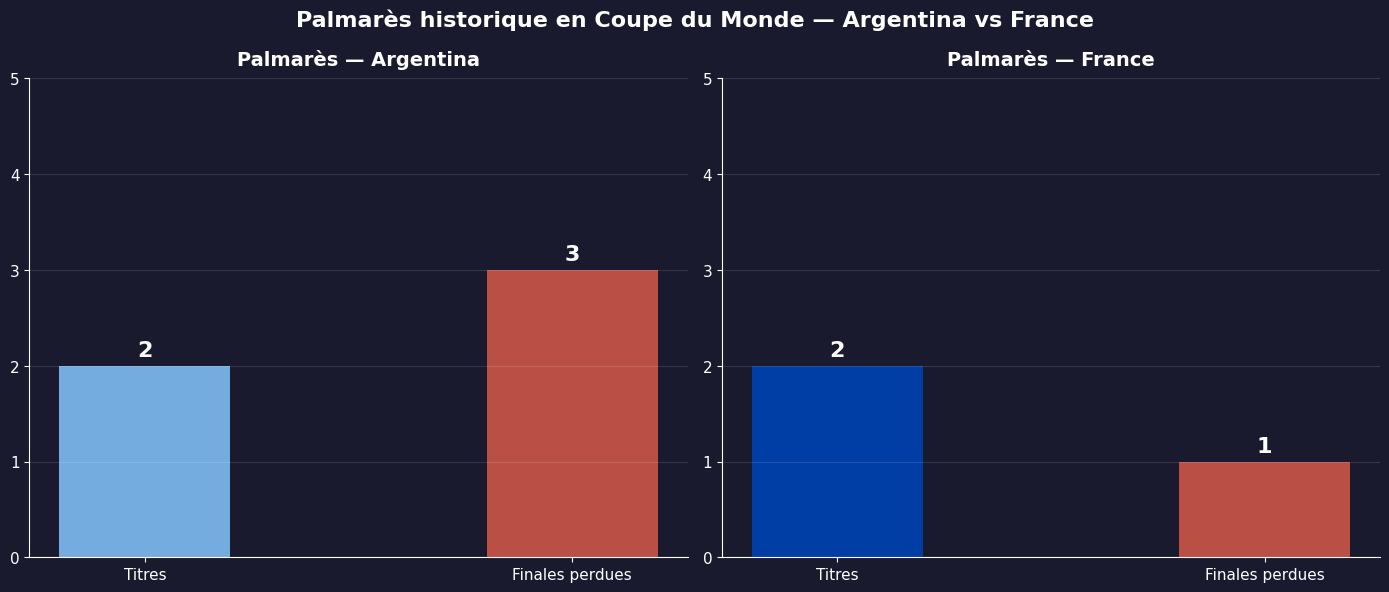

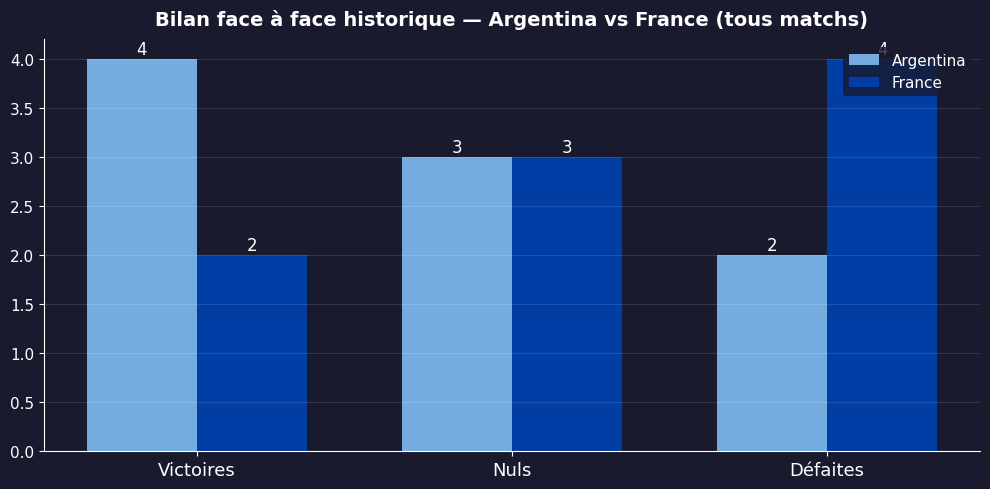

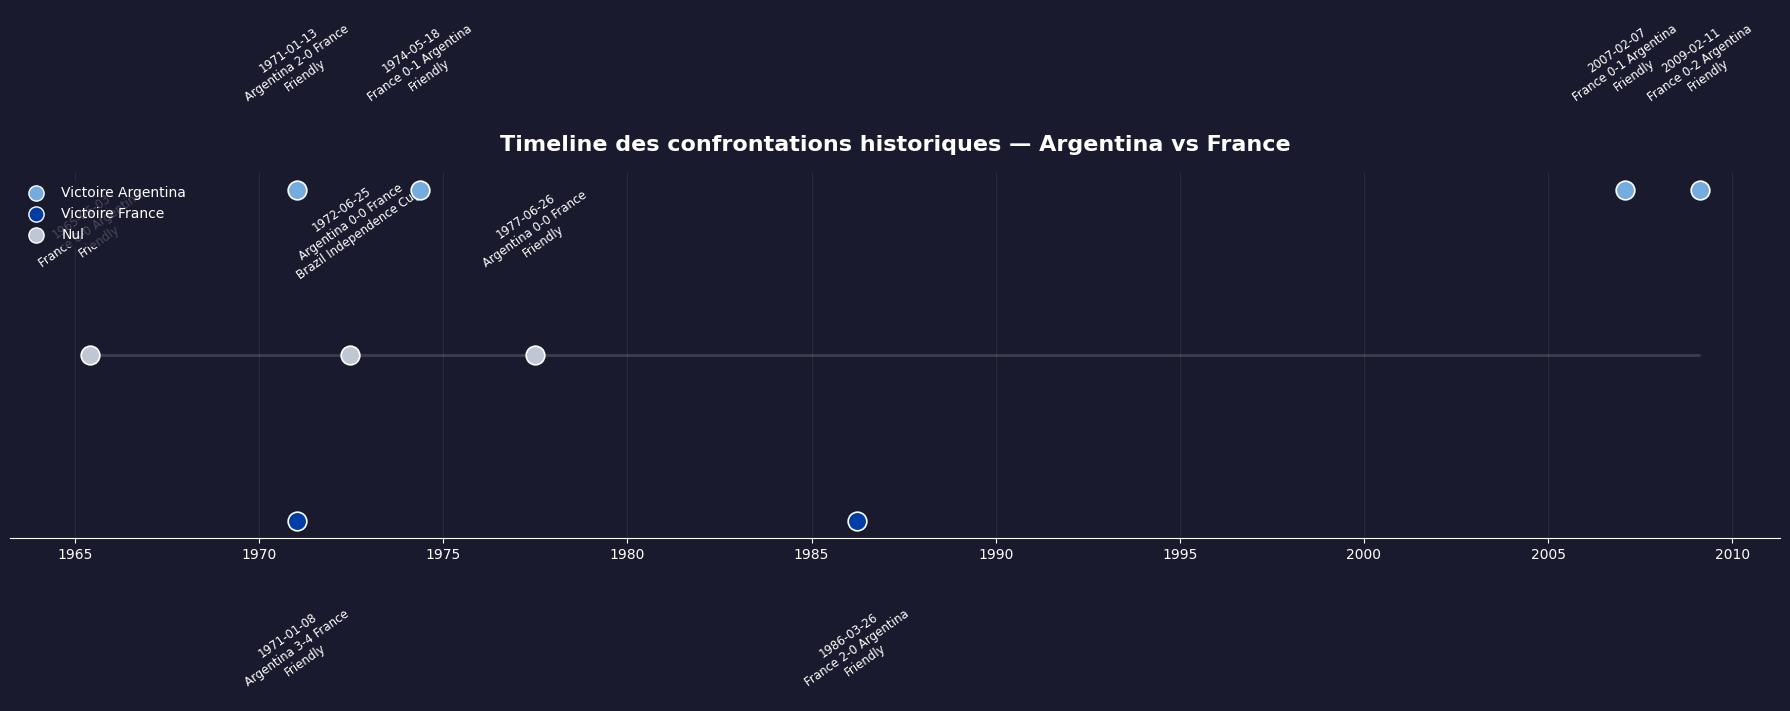

In [4]:

# ============================================================
# SECTION 1 — HISTOIRE DU FOOTBALL
# ============================================================

# --- 1a) Palmarès historique côte à côte ---

fig, axs = plt.subplots(1, 2, figsize=(14, 6))
fig.set_facecolor(BG)

for ax, team_name, color in zip(axs, ["Argentina", "France"], [ARG, FRA]):
    style_ax(ax)
    titres  = palmares_df.loc[palmares_df["team"] == team_name, "titles"].values[0]
    finales = palmares_df.loc[palmares_df["team"] == team_name, "lost_finals"].values[0]
    bars = ax.bar(["Titres", "Finales perdues"], [titres, finales],
                  color=[color, LOSS], width=0.4)
    ax.set_ylim(0, 5)
    ax.set_title(f"Palmarès — {team_name}", fontsize=14, color=FG, fontweight="bold", pad=10)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(int(bar.get_height())), ha="center", color=FG,
                fontsize=16, fontweight="bold")

fig.suptitle("Palmarès historique en Coupe du Monde — Argentina vs France",
             fontsize=16, color=FG, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/01_palmares_historique.png", dpi=150, facecolor=BG, bbox_inches="tight")
plt.show()

# --- 1b) Bilan face à face historique ---

def calc_wins(df, team):
    home_wins = df[(df["Home Team"] == team) & (df["Home Goals"] > df["Away Goals"])]
    away_wins = df[(df["Away Team"] == team) & (df["Away Goals"] > df["Home Goals"])]
    draws = df[
        ((df["Home Team"] == team) | (df["Away Team"] == team)) &
        (df["Home Goals"] == df["Away Goals"])
    ]
    total = len(df[(df["Home Team"] == team) | (df["Away Team"] == team)])
    return {
        "Victoires": len(home_wins) + len(away_wins),
        "Nuls":      len(draws),
        "Défaites":  total - len(home_wins) - len(away_wins) - len(draws),
    }

stats_arg = calc_wins(h2h, "Argentina")
stats_fra = calc_wins(h2h, "France")

fig, ax = plt.subplots(figsize=(10, 5))
fig.set_facecolor(BG)
style_ax(ax)

categories = ["Victoires", "Nuls", "Défaites"]
x = np.arange(len(categories))
width = 0.35

bars1 = ax.bar(x - width/2, [stats_arg[c] for c in categories], width, label="Argentina", color=ARG)
bars2 = ax.bar(x + width/2, [stats_fra[c]  for c in categories], width, label="France",    color=FRA)

ax.set_xticks(list(x))
ax.set_xticklabels(categories, color=FG, fontsize=13)
ax.set_title("Bilan face à face historique — Argentina vs France (tous matchs)",
             fontsize=14, color=FG, fontweight="bold", pad=10)

legend = ax.legend(facecolor=BG, edgecolor="none", fontsize=11, loc="upper right")
for text in legend.get_texts():
    text.set_color(FG)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                str(int(bar.get_height())), ha="center", color=FG, fontsize=12)

plt.tight_layout()
plt.savefig("../reports/figures/02_bilan_face_a_face.png", dpi=150, facecolor=BG, bbox_inches="tight")
plt.show()

# --- 1c) Timeline des confrontations historiques ---

fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

plot_df = h2h_hist.dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)
ax.hlines(y=0, xmin=plot_df["Date"].min(), xmax=plot_df["Date"].max(),
          color="white", alpha=0.15, linewidth=2)

for _, row in plot_df.iterrows():
    if row["winner"] == "Argentina":
        color, y = ARG, 0.18
    elif row["winner"] == "France":
        color, y = FRA, -0.18
    else:
        color, y = NEUTRAL, 0

    ax.scatter(row["Date"], y, s=180, color=color, edgecolor="white", linewidth=1.2, zorder=3)
    label = f'{row["Date"].strftime("%Y-%m-%d")}\n{row["score"]}\n{row["Tournament"]}'
    ax.text(row["Date"], y + (0.08 if y >= 0 else -0.08), label,
            color=FG, fontsize=8.5, ha="center",
            va="bottom" if y >= 0 else "top", rotation=35)

# Légende
for label, color in [("Victoire Argentina", ARG), ("Victoire France", FRA), ("Nul", NEUTRAL)]:
    ax.scatter([], [], color=color, edgecolor="white", s=120, label=label)
leg = ax.legend(facecolor=BG, edgecolor="none", fontsize=10, loc="upper left")
for text in leg.get_texts():
    text.set_color(FG)

ax.set_title("Timeline des confrontations historiques — Argentina vs France",
             color=FG, fontsize=16, pad=16, fontweight="bold")
ax.set_yticks([])
ax.tick_params(axis="x", colors=FG)
ax.spines["bottom"].set_color(FG)
for sp in ["left", "top", "right"]:
    ax.spines[sp].set_visible(False)
ax.grid(axis="x", color="white", alpha=0.08)

plt.tight_layout()
plt.savefig("../reports/figures/03_h2h_timeline.png", dpi=180, facecolor=BG, bbox_inches="tight")
plt.show()





<details open>
<summary>French version</summary>

## Lecture des resultats - Contexte 2022

Les deux finalistes arrivent au Qatar avec un niveau percu comme tres proche. Le classement FIFA place l'**Argentine 3e** et la **France 4e** avant le tournoi, ce qui confirme l'idee d'une finale entre deux favoris majeurs plutot qu'entre un favori net et un outsider.

Le rappel des confrontations en Coupe du Monde nuance toutefois ce constat. L'Argentine s'etait imposee en **1930** et en **1978**, alors que la France avait pris sa revanche en **2018** avec une victoire **4-3** en huitieme de finale. La finale 2022 prolonge donc une rivalite a la fois historique et recente.

Cette section montre ainsi que la finale se joue dans un contexte d'equilibre competitif fort, renforce par un passe commun deja dense entre les deux nations.

</details>

<details>
<summary>English version</summary>

## Reading the Results - 2022 Context

The two finalists arrived in Qatar with a very similar perceived level. The FIFA ranking placed **Argentina 3rd** and **France 4th** before the tournament, which confirms the idea of a final between two major favorites rather than between a clear favorite and an outsider.

The reminder of their World Cup meetings nevertheless adds nuance. Argentina had won in **1930** and **1978**, while France took revenge in **2018** with a **4-3** victory in the round of 16. The 2022 final therefore extends a rivalry that is both historical and recent.

This section shows that the final takes place in a context of strong competitive balance, reinforced by a shared football history that is already quite dense between the two nations.

</details>


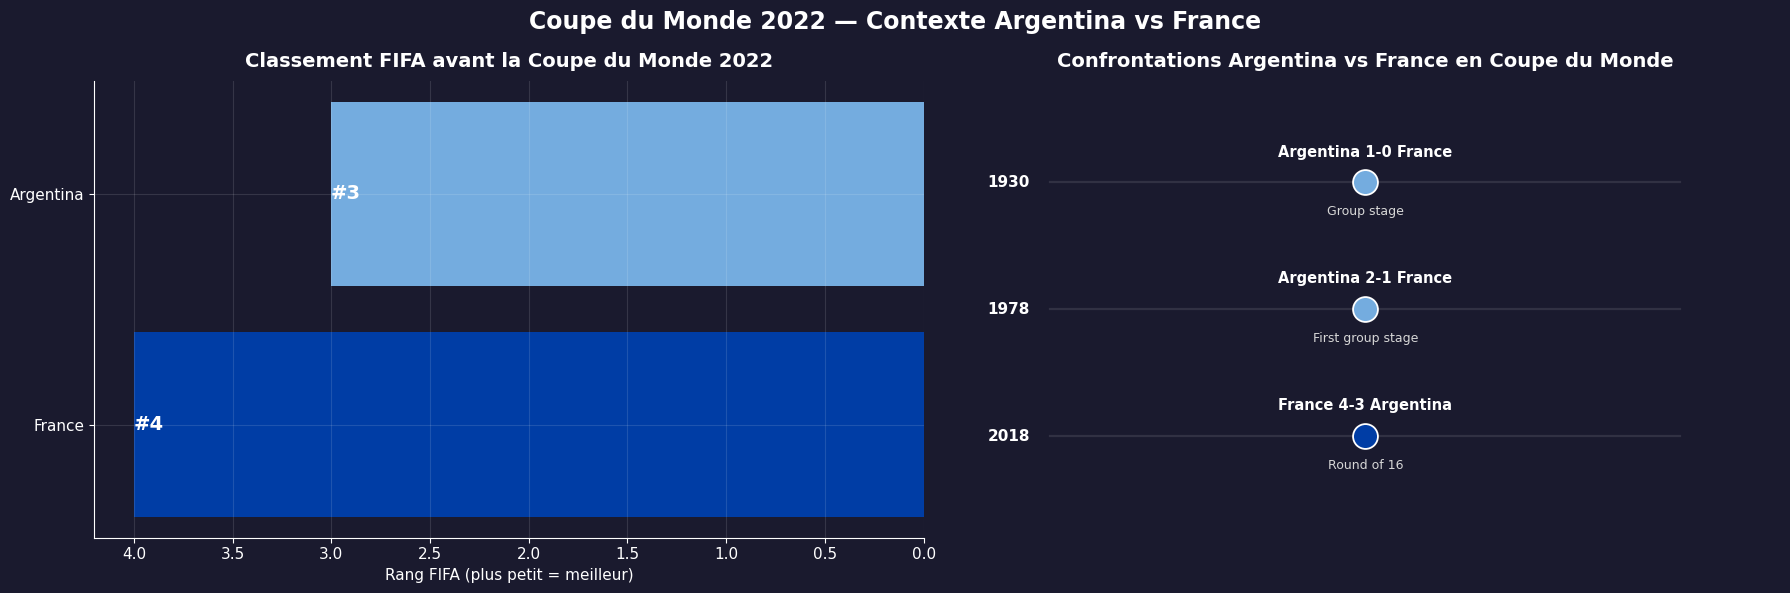

In [5]:
# ============================================================
# SECTION 2 — COUPE DU MONDE 2022 — CONTEXTE
# ============================================================
# --- 2a) Classement FIFA + confrontations CDM côte à côte ---

fig, axs = plt.subplots(1, 2, figsize=(18, 6))
fig.set_facecolor(BG)

# Classement FIFA
ax = axs[0]
style_ax(ax)
ranking_plot = ranking_pre_wc.sort_values("fifa_rank", ascending=False).copy()
bars = ax.barh(
    ranking_plot["team"],
    ranking_plot["fifa_rank"],
    color=[ARG if t == "Argentina" else FRA for t in ranking_plot["team"]]
)
ax.set_title("Classement FIFA avant la Coupe du Monde 2022",
             color=FG, fontsize=14, fontweight="bold", pad=10)
ax.set_xlabel("Rang FIFA (plus petit = meilleur)", color=FG, fontsize=11)
ax.grid(axis="x", color="white", alpha=0.12)
ax.invert_xaxis()
for bar, row in zip(bars, ranking_plot.itertuples()):
    ax.text(bar.get_width() - 0.15, bar.get_y() + bar.get_height()/2,
            f"#{int(row.fifa_rank)}", va="center", ha="right",
            color=FG, fontsize=14, fontweight="bold")

# Confrontations CDM
ax = axs[1]
ax.set_facecolor(BG)
wc_plot = wc_h2h.sort_values("Year").copy()
wc_plot = wc_plot.rename(columns={
    "Home Team": "home_team", "Away Team": "away_team",
    "Home Goals": "home_goals", "Away Goals": "away_goals",
    "Year": "year", "Stage": "stage"
})
ypos = np.arange(len(wc_plot))[::-1]
ax.set_xlim(0, 10)
ax.set_ylim(-0.8, len(wc_plot) - 0.2)

for i, row in enumerate(wc_plot.itertuples(index=False)):
    y = ypos[i]
    winner = row.home_team if row.home_goals > row.away_goals else \
             (row.away_team if row.away_goals > row.home_goals else "Draw")
    color = ARG if winner == "Argentina" else (FRA if winner == "France" else NEUTRAL)

    ax.plot([1.2, 8.8], [y, y], color="white", alpha=0.10, linewidth=1.6)
    ax.scatter(5, y, s=320, color=color, edgecolor="white", linewidth=1.3, zorder=3)
    ax.text(0.7, y, str(row.year), color=FG, va="center", ha="center",
            fontsize=11, fontweight="bold")
    ax.text(5, y + 0.18, f"{row.home_team} {row.home_goals}-{row.away_goals} {row.away_team}",
            color=FG, va="bottom", ha="center", fontsize=10.5, fontweight="bold")
    ax.text(5, y - 0.18, row.stage, color="#d6d6d6", va="top", ha="center", fontsize=9)

ax.set_title("Confrontations Argentina vs France en Coupe du Monde",
             color=FG, fontsize=14, fontweight="bold", pad=10)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

fig.suptitle("Coupe du Monde 2022 — Contexte Argentina vs France",
             fontsize=17, color=FG, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/04_contexte_wc2022.png", dpi=150, facecolor=BG, bbox_inches="tight")
plt.show()


<details open>
<summary>French version</summary>

## Lecture des resultats - Danger passes

Les danger passes mettent en evidence une opposition de styles. Sur l'ensemble de la Coupe du Monde 2022, la **France totalise 217 danger passes**, soit **31,0 par match**, contre **162** pour l'**Argentine**, soit **23,14 par match**. Le volume francais est donc plus eleve.

La repartition spatiale nuance cependant cette superiorite quantitative. L'Argentine agit en moyenne plus haut sur le terrain (**x moyen 85,08**) que la France (**81,37**). En revanche, la France concentre davantage ses sequences sur le cote gauche (**47,0 %** des danger passes), tandis que l'Argentine passe plus souvent par la droite (**43,2 %**).

L'analyse par joueur confirme cette lecture. Cote argentin, **Lionel Messi** domine avec **4,43 danger passes par match**, devant **Rodrigo De Paul** et **Alexis Mac Allister** (**3,29** chacun). Cote francais, **Kylian Mbappe** mene avec **4,86**, suivi d'**Antoine Griezmann** (**4,29**) et de **Theo Hernandez** (**3,43**). La France ressort donc comme plus productive en volume, tandis que l'Argentine apparait plus haute et plus lateralisee a droite.

</details>

<details>
<summary>English version</summary>

## Reading the Results - Danger Passes

Danger passes highlight a contrast in styles. Across the 2022 World Cup, **France recorded 217 danger passes**, or **31.0 per match**, compared with **162** for **Argentina**, or **23.14 per match**. The French volume is therefore higher.

The spatial distribution, however, nuances that quantitative edge. Argentina acts on average higher up the pitch (**average x at 85.08**) than France (**81.37**). By contrast, France concentrates more of its sequences on the left side (**47.0%** of danger passes), while Argentina uses the right side more often (**43.2%**).

The player-level analysis confirms that reading. On the Argentine side, **Lionel Messi** leads with **4.43 danger passes per match**, ahead of **Rodrigo De Paul** and **Alexis Mac Allister** (**3.29** each). On the French side, **Kylian Mbapp?** leads with **4.86**, followed by **Antoine Griezmann** (**4.29**) and **Theo Hernandez** (**3.43**). France therefore emerges as more productive in volume, while Argentina appears higher on the pitch and more right-oriented.

</details>


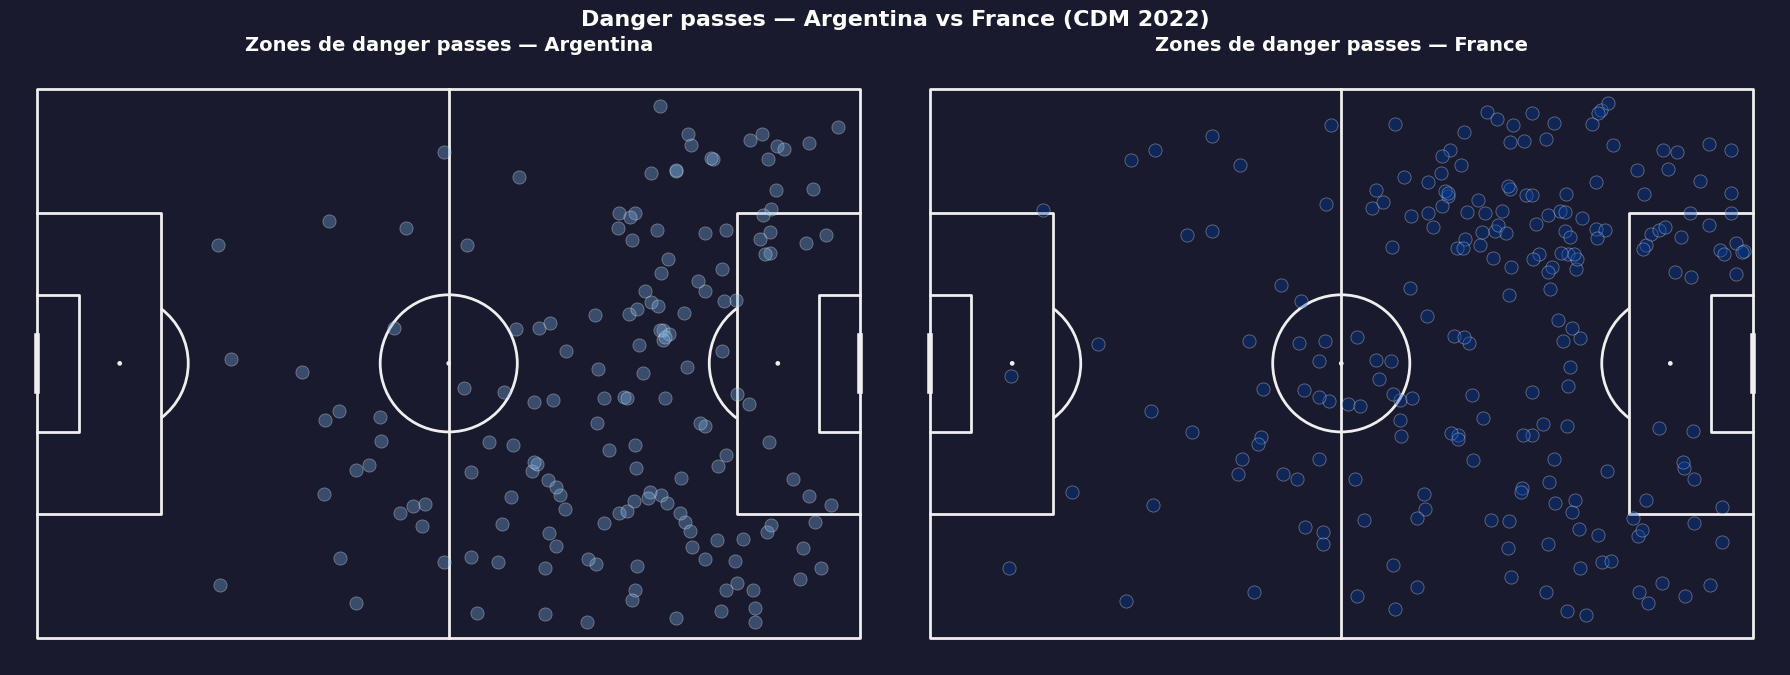

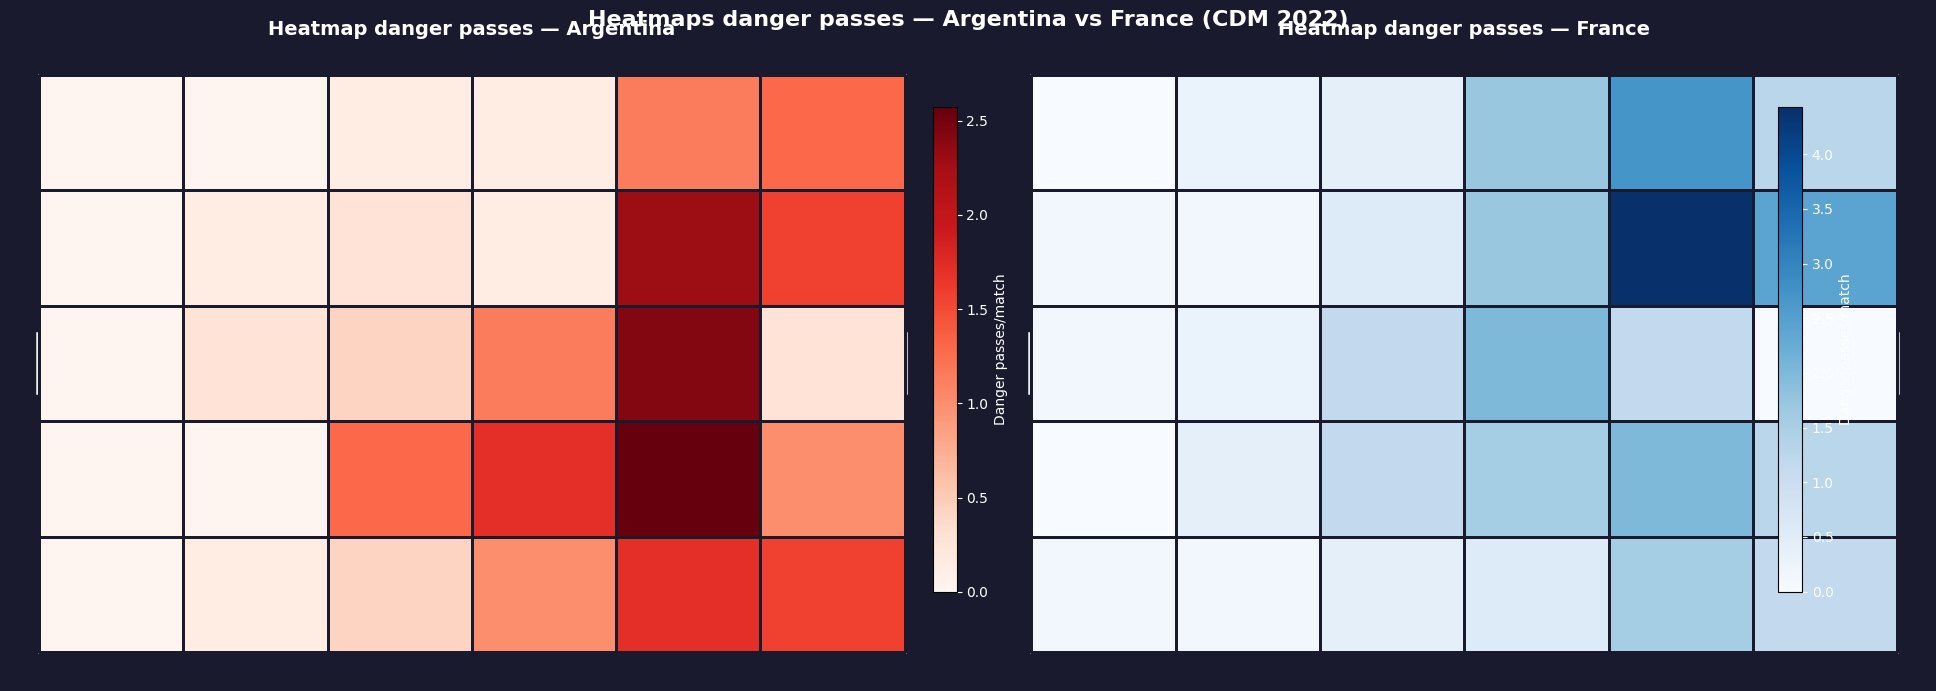

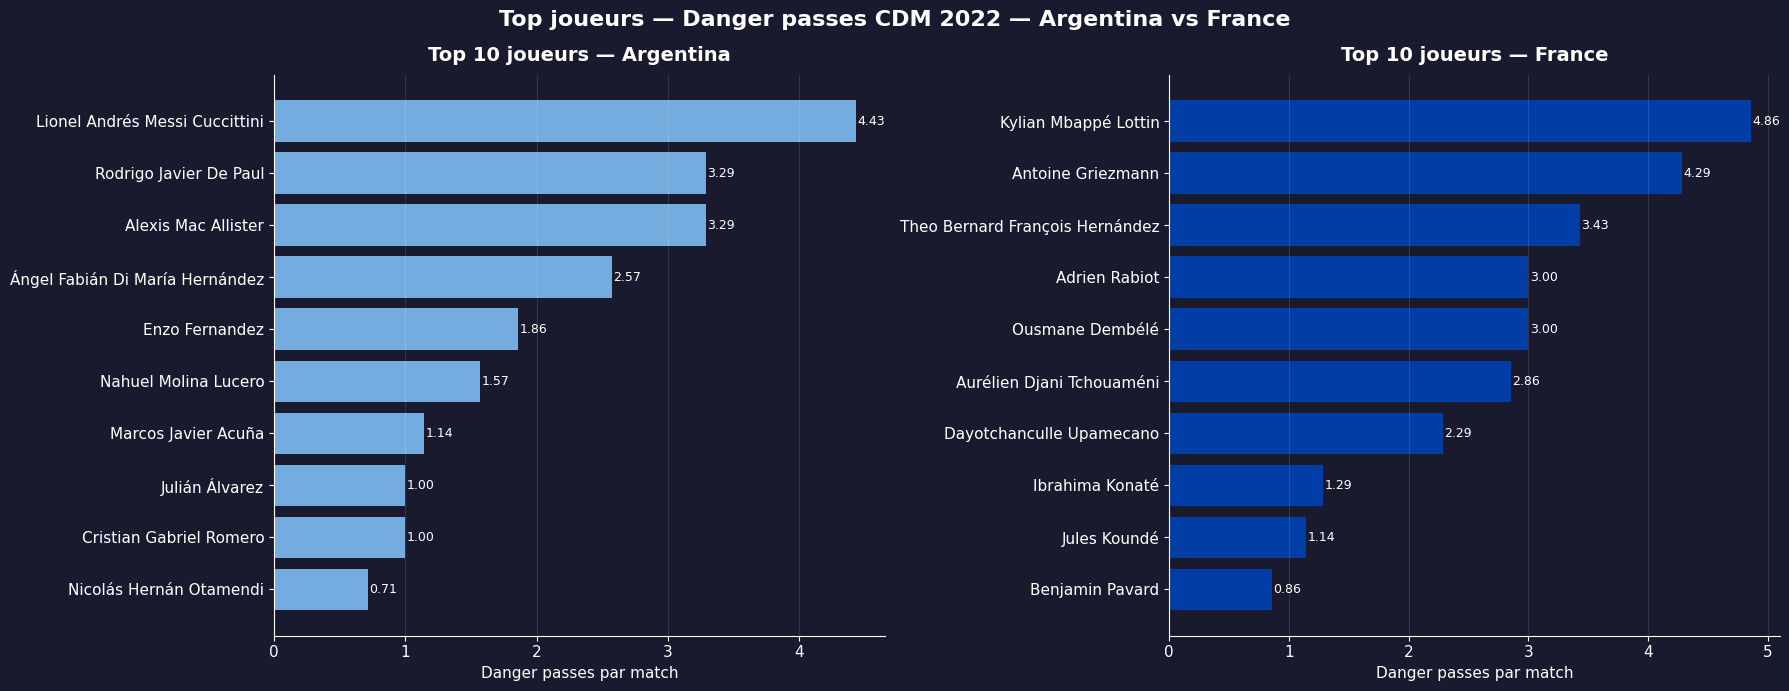

In [6]:


# ============================================================
# SECTION 3 — DANGER PASSES CDM 2022
# ============================================================

# --- 3a) Scatter zones côte à côte ---

pitch = Pitch(line_color="#efefef", pitch_color=BG)
fig, axs = plt.subplots(1, 2, figsize=(18, 7))
fig.set_facecolor(BG)

for ax, dp, team_name, color in zip(
    axs,
    [danger_passes, danger_passes_france],
    ["Argentina", "France"],
    [ARG, FRA]
):
    pitch.draw(ax=ax)
    pitch.scatter(dp.x, dp.y, s=90, color=color,
                  edgecolors="white", linewidth=0.6, alpha=0.35, ax=ax)
    ax.set_title(f"Zones de danger passes — {team_name}",
                 color=FG, fontsize=14, fontweight="bold", pad=8)

fig.suptitle("Danger passes — Argentina vs France (CDM 2022)",
             fontsize=16, color=FG, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/05_danger_passes_scatter.png", dpi=150, facecolor=BG, bbox_inches="tight")
plt.show()




# --- 3b) Heatmaps côte à côte ---

fig, axs = plt.subplots(1, 2, figsize=(20, 7))
fig.set_facecolor(BG)

configs = [
    (danger_passes,        no_games_arg, "Argentina", "Reds",  ARG),
    (danger_passes_france, no_games_fra, "France",    "Blues", FRA),
]

for ax, (dp, n_games, team_name, cmap, _color) in zip(axs, configs):
    pitch.draw(ax=ax)
    bin_stat = pitch.bin_statistic(dp.x, dp.y, statistic="count", bins=(6, 5), normalize=False)
    bin_stat["statistic"] = bin_stat["statistic"] / n_games
    pcm = pitch.heatmap(bin_stat, cmap=cmap, edgecolor=BG, ax=ax)
    ax.set_title(f"Heatmap danger passes — {team_name}",
                 color=FG, fontsize=14, fontweight="bold", pad=8)

    cbar_ax = fig.add_axes([
        ax.get_position().x1 + 0.005,
        ax.get_position().y0,
        0.012,
        ax.get_position().height
    ])
    cbar = plt.colorbar(pcm, cax=cbar_ax)
    cbar.set_label("Danger passes/match", fontsize=10, color=FG)
    cbar.ax.yaxis.set_tick_params(color=FG)
    plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color=FG)

fig.suptitle("Heatmaps danger passes — Argentina vs France (CDM 2022)",
             fontsize=16, color=FG, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/06_danger_passes_heatmaps.png", dpi=150, facecolor=BG, bbox_inches="tight")
plt.show()





# --- 3c) Top 10 joueurs côte à côte ---

fig, axs = plt.subplots(1, 2, figsize=(18, 7))
fig.set_facecolor(BG)

for ax, dp, n_games, team_name, color in zip(
    axs,
    [danger_passes, danger_passes_france],
    [no_games_arg, no_games_fra],
    ["Argentina", "France"],
    [ARG, FRA]
):
    style_ax(ax)
    top = (dp.groupby("player_name").x.count() / n_games).sort_values(ascending=False).head(10)
    bars = ax.barh(top.index, top.values, color=color)
    ax.invert_yaxis()
    ax.set_xlabel("Danger passes par match", color=FG, fontsize=11)
    ax.set_title(f"Top 10 joueurs — {team_name}", color=FG, fontsize=14, fontweight="bold", pad=10)
    ax.grid(axis="x", color="white", alpha=0.12)
    ax.grid(axis="y", alpha=0)

    for bar, val in zip(bars, top.values):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.2f}", va="center", fontsize=9, color=FG)

fig.suptitle("Top joueurs — Danger passes CDM 2022 — Argentina vs France",
             fontsize=16, color=FG, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/07_top_joueurs_danger.png", dpi=150, facecolor=BG, bbox_inches="tight")
plt.show()



<details open>
<summary>French version</summary>

## Lecture des resultats - Synthese

Le dashboard resume bien l'equilibre global de cette affiche. Historiquement, les deux nations comptent **2 titres mondiaux chacune**, mais l'Argentine conserve un leger avantage dans les confrontations directes. Dans le meme temps, le contexte pre-tournoi montre deux equipes pratiquement au meme niveau dans la hierarchie internationale, avec seulement un rang d'ecart au classement FIFA.

Sur le plan offensif, la donne s'inverse partiellement. La France produit plus de danger passes en volume, alors que l'Argentine semble construire ses actions plus haut sur le terrain. L'une parait plus explosive dans la frequence des sequences menant au tir, l'autre plus installee dans la progression et l'occupation des zones avancees.

Au final, les visualisations convergent vers la meme idee: la finale 2022 oppose deux equipes de niveau historique comparable, mais avec des mecanismes offensifs differents. C'est cette combinaison entre equilibre global et contraste tactique qui rend la confrontation aussi riche a analyser.

</details>

<details>
<summary>English version</summary>

## Reading the Results - Summary

The dashboard captures the overall balance of this matchup quite well. Historically, the two nations each have **2 World Cup titles**, but Argentina keeps a slight edge in direct confrontations. At the same time, the pre-tournament context shows two teams at almost the same level in the international hierarchy, with only one ranking place between them in the FIFA standings.

From an attacking perspective, the picture shifts somewhat. France produces more danger passes in volume, whereas Argentina seems to build its actions from higher areas of the pitch. One side looks more explosive in the frequency of shot-leading sequences, the other more settled in progression and occupation of advanced zones.

In the end, the visualizations converge toward the same idea: the 2022 final opposes two teams of comparable historical status, but with different attacking mechanisms. It is this combination of overall balance and tactical contrast that makes the matchup so rich to analyze.

</details>


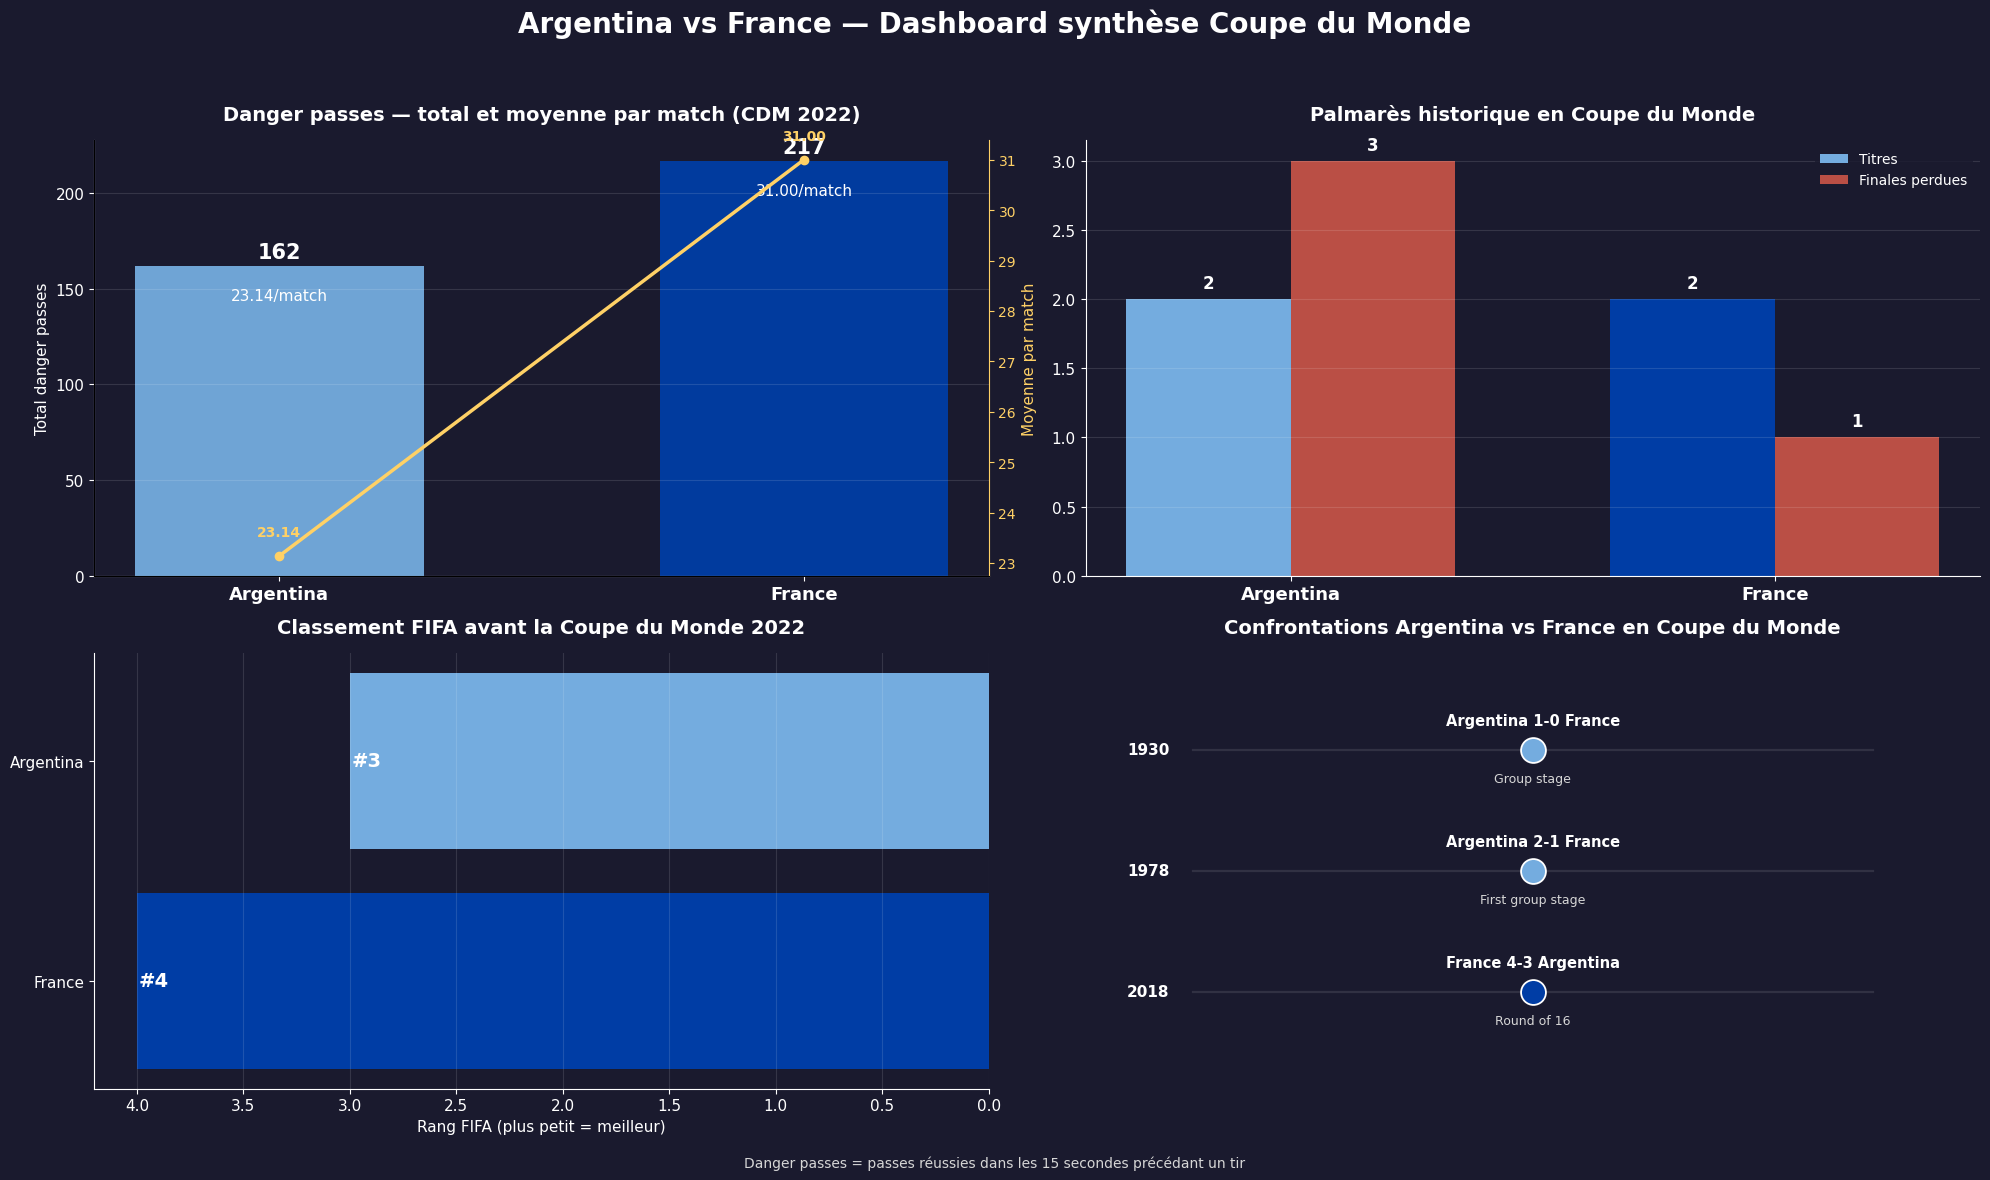

In [7]:

# ============================================================
# SECTION 4 — DASHBOARD SYNTHÈSE
# ============================================================

fig, axs = plt.subplots(2, 2, figsize=(20, 12), squeeze=False)
fig.patch.set_facecolor(BG)

for ax in axs.flat:
    style_ax(ax)

# ---------------- 4a) Danger passes total + moyenne ----------------
ax = axs[0, 0]
teams_labels = summary_danger["team"].tolist()
totals = summary_danger["total_danger_passes"].tolist()
means  = summary_danger["danger_passes_per_match"].tolist()
colors = [ARG, FRA]
x = np.arange(len(teams_labels))

bars = ax.bar(x, totals, color=colors, width=0.55, alpha=0.95)
ax.set_xticks(x)
ax.set_xticklabels(teams_labels, color=FG, fontsize=13, fontweight="bold")
ax.set_ylabel("Total danger passes", color=FG, fontsize=11)
ax.set_title("Danger passes — total et moyenne par match (CDM 2022)",
             color=FG, fontsize=14, fontweight="bold", pad=14)

for bar, total, mean in zip(bars, totals, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
            f"{total}", ha="center", color=FG, fontsize=15, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 18,
            f"{mean:.2f}/match", ha="center", color=FG, fontsize=11)

ax2 = ax.twinx()
ax2.set_facecolor(BG)
ax2.plot(x, means, marker="o", linewidth=2.5, color=ACCENT)
ax2.set_ylabel("Moyenne par match", color=ACCENT, fontsize=11)
ax2.tick_params(colors=ACCENT)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_color(ACCENT)
for xi, m in zip(x, means):
    ax2.text(xi, m + 0.4, f"{m:.2f}", color=ACCENT, ha="center", fontsize=10, fontweight="bold")

# ---------------- 4b) Palmarès historique ----------------
ax = axs[0, 1]
x = np.arange(len(palmares_df))
width = 0.34
bars_t = ax.bar(x - width/2, palmares_df["titles"],     width, color=[ARG, FRA], label="Titres")
bars_l = ax.bar(x + width/2, palmares_df["lost_finals"], width, color=LOSS,       label="Finales perdues")
ax.set_xticks(x)
ax.set_xticklabels(palmares_df["team"], color=FG, fontsize=13, fontweight="bold")
ax.set_title("Palmarès historique en Coupe du Monde",
             color=FG, fontsize=14, fontweight="bold", pad=14)
leg = ax.legend(facecolor=BG, edgecolor="none", fontsize=10, loc="upper right")
for t in leg.get_texts():
    t.set_color(FG)
for bars in [bars_t, bars_l]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
                f"{int(bar.get_height())}", ha="center", color=FG, fontsize=12, fontweight="bold")

# ---------------- 4c) Classement FIFA ----------------
ax = axs[1, 0]
ranking_plot = ranking_pre_wc.sort_values("fifa_rank", ascending=False).copy()
bars = ax.barh(
    ranking_plot["team"], ranking_plot["fifa_rank"],
    color=[ARG if t == "Argentina" else FRA for t in ranking_plot["team"]]
)
ax.set_title("Classement FIFA avant la Coupe du Monde 2022",
             color=FG, fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Rang FIFA (plus petit = meilleur)", color=FG, fontsize=11)
ax.grid(axis="x", color="white", alpha=0.12)
ax.grid(axis="y", alpha=0)
ax.invert_xaxis()
for bar, row in zip(bars, ranking_plot.itertuples()):
    ax.text(bar.get_width() - 0.15, bar.get_y() + bar.get_height()/2,
            f"#{int(row.fifa_rank)}", va="center", ha="right",
            color=FG, fontsize=14, fontweight="bold")

# ---------------- 4d) Confrontations CDM ----------------
ax = axs[1, 1]
wc_plot = wc_h2h.sort_values("Year").copy()
wc_plot = wc_plot.rename(columns={
    "Home Team": "home_team", "Away Team": "away_team",
    "Home Goals": "home_goals", "Away Goals": "away_goals",
    "Year": "year", "Stage": "stage"
})
ypos = np.arange(len(wc_plot))[::-1]
ax.set_xlim(0, 10)
ax.set_ylim(-0.8, len(wc_plot) - 0.2)

for i, row in enumerate(wc_plot.itertuples(index=False)):
    y = ypos[i]
    winner = row.home_team if row.home_goals > row.away_goals else \
             (row.away_team if row.away_goals > row.home_goals else "Draw")
    color = ARG if winner == "Argentina" else (FRA if winner == "France" else NEUTRAL)
    ax.plot([1.2, 8.8], [y, y], color="white", alpha=0.10, linewidth=1.6)
    ax.scatter(5, y, s=320, color=color, edgecolor="white", linewidth=1.3, zorder=3)
    ax.text(0.7, y, str(row.year), color=FG, va="center", ha="center",
            fontsize=11, fontweight="bold")
    ax.text(5, y + 0.18, f"{row.home_team} {row.home_goals}-{row.away_goals} {row.away_team}",
            color=FG, va="bottom", ha="center", fontsize=10.5, fontweight="bold")
    ax.text(5, y - 0.18, row.stage, color="#d6d6d6", va="top", ha="center", fontsize=9)

ax.set_title("Confrontations Argentina vs France en Coupe du Monde",
             color=FG, fontsize=14, fontweight="bold", pad=14)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Titre global
fig.suptitle("Argentina vs France — Dashboard synthèse Coupe du Monde",
             fontsize=20, color=FG, fontweight="bold", y=0.98)
fig.text(0.5, 0.015,
         "Danger passes = passes réussies dans les 15 secondes précédant un tir",
         ha="center", color="#d6d6d6", fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("../reports/figures/08_dashboard_synthese.png", dpi=180, facecolor=BG, bbox_inches="tight")
plt.show()



In [8]:

# ============================================================
# SAUVEGARDE DES DONNÉES TRAITÉES
# ============================================================

h2h.to_csv("../data/processed/h2h_arg_fra.csv", index=False)
arg_vs_fra.to_csv("../data/processed/wc_arg_vs_fra.csv", index=False)
danger_passes.to_csv("../data/processed/danger_passes_argentina.csv", index=False)
danger_passes_france.to_csv("../data/processed/danger_passes_france.csv", index=False)